# Lista 02 - Estatística

**Questão 01 - Usando o mesmo portfolio da sua lista anterior, normalize os retornos logarítmicos,( z-score). O que ele significa?**

In [33]:
import pandas as pd
import numpy as np

df = pd.read_csv("/Users/mariajuliabongiovanni/Documents/quant/lista-02-majubongiovanni-design-1/Portfolio_lista2.csv")

df = df.rename(columns={
    "Fechamento|ajust p/ prov|Em moeda orig|ABEV3": "ABEV3",
    "Fechamento|ajust p/ prov|Em moeda orig|BBDC4": "BBDC4",
    "Fechamento|ajust p/ prov|Em moeda orig|ITUB4": "ITUB4",
    "Fechamento|ajust p/ prov|Em moeda orig|PETR4": "PETR4",
    "Fechamento|ajust p/ prov|Em moeda orig|VALE3": "VALE3",
    "Fechamento|ajust p/ prov|Em moeda orig|IBOV": "IBOV"
})


df["Data"] = pd.to_datetime(df["Data"])

ativos = ["ABEV3", "BBDC4", "ITUB4", "PETR4", "VALE3", "IBOV"]

for ativo in ativos:
    df[ativo] = pd.to_numeric(df[ativo], errors="coerce")

for ativo in ativos:
    df[f"log_ret_{ativo}"] = np.log(df[ativo] / df[ativo].shift(1))

df = df.dropna().copy()

for ativo in ativos:
    media = df[f"log_ret_{ativo}"].mean()
    desvio = df[f"log_ret_{ativo}"].std()
    df[f"z_{ativo}"] = (df[f"log_ret_{ativo}"] - media) / desvio

print(df.head())

         Ativo       Data      ABEV3     BBDC4      ITUB4     PETR4  \
2  VALE3<XBSP> 2017-01-03  11.227690  9.330280   9.790312  3.893804   
3  VALE3<XBSP> 2017-01-04  11.139973  9.271188   9.832331  3.893804   
4  VALE3<XBSP> 2017-01-05  11.200700  9.373822   9.966790  3.956608   
5  VALE3<XBSP> 2017-01-06  11.106236  9.432913  10.000405  3.933998   
6  VALE3<XBSP> 2017-01-09  11.153468  9.445354  10.048026  3.851098   

       VALE3     IBOV  log_ret_ABEV3  log_ret_BBDC4  log_ret_ITUB4  \
2  13.016467  61813.0       0.020031       0.041481       0.041478   
3  12.782698  61589.0      -0.007843      -0.006353       0.004283   
4  13.270132  62070.0       0.005436       0.011009       0.013583   
5  12.916991  61665.0      -0.008470       0.006284       0.003367   
6  13.180603  61700.0       0.004244       0.001318       0.004751   

   log_ret_PETR4  log_ret_VALE3  log_ret_IBOV   z_ABEV3   z_BBDC4   z_ITUB4  \
2       0.055717       0.043341      0.036659  1.200140  1.933354  2.2786

O z-score mede quantos desvios padrão um valor está em relação à média. Ele permite identificar se um retorno está acima ou abaixo do comportamento médio esperado, além de possibilitar a comparação entre diferentes ativos em uma mesma escala.

**Hello World!**

**Questão 02 - Com os retornos normalizados, plote um histograma deles. Também adicione uma curva de gauss e 3 curvas de t-student com n = 5,10 e 50. O que difere a t-student da curva gaussiana?**

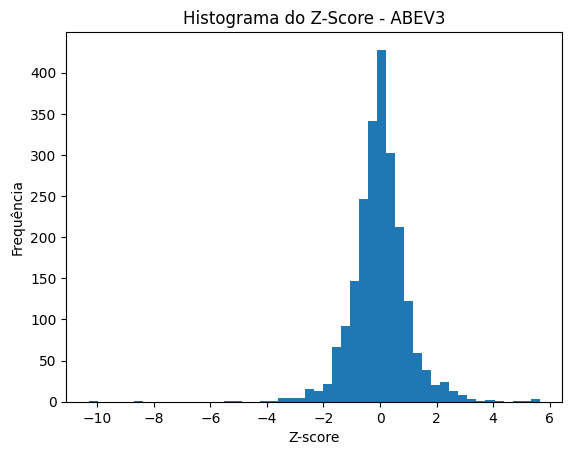

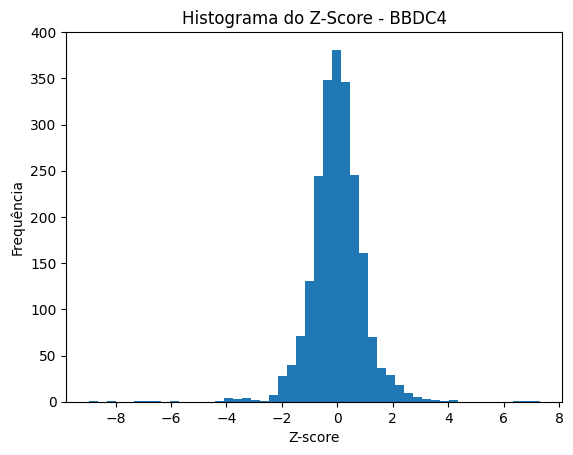

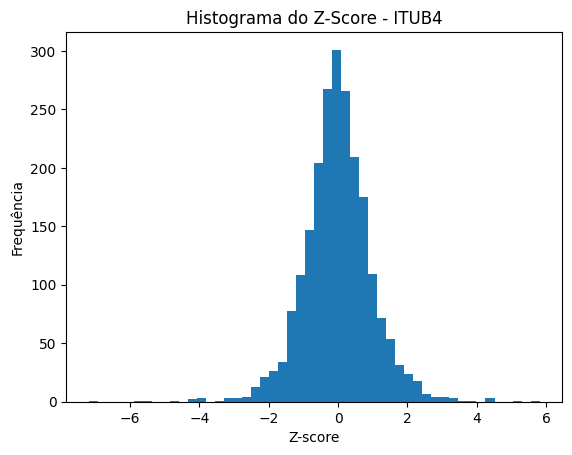

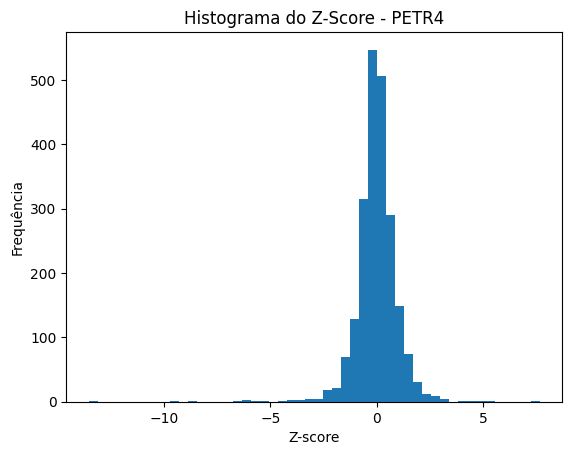

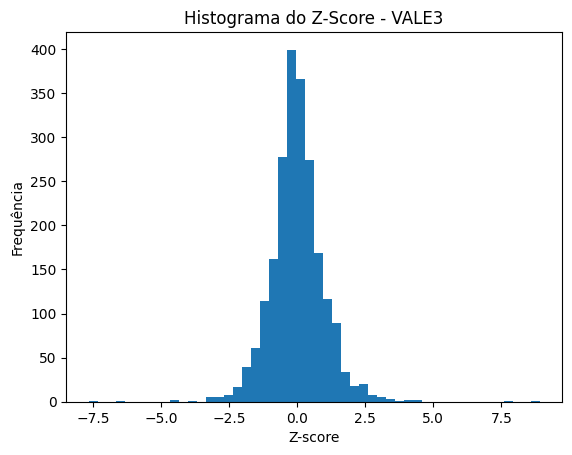

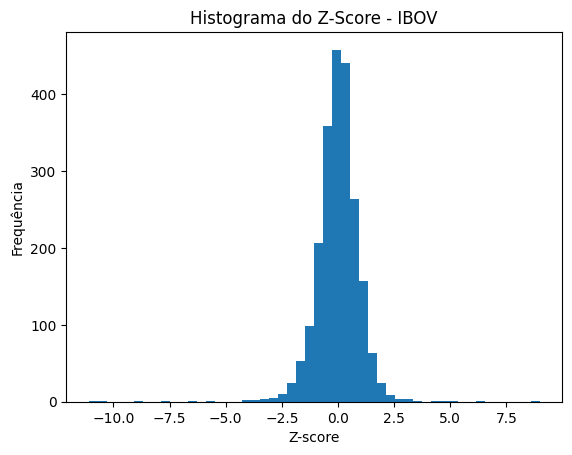

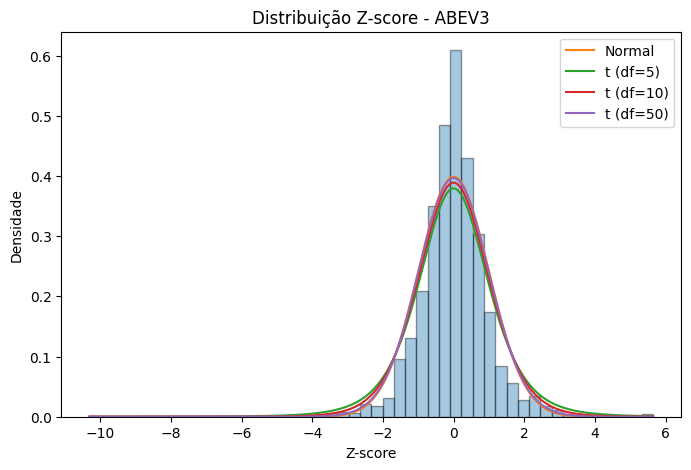

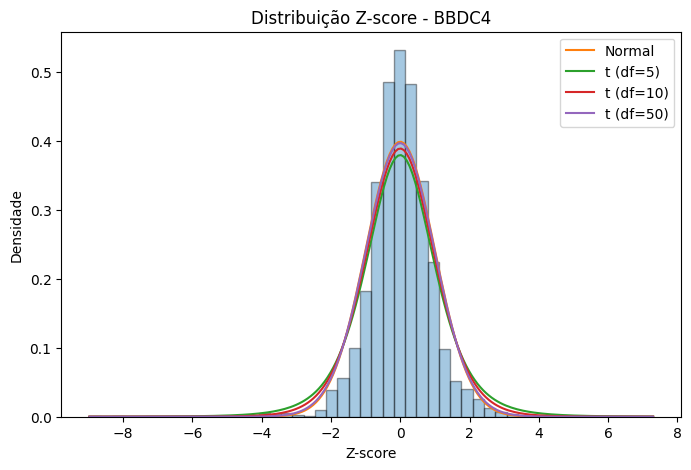

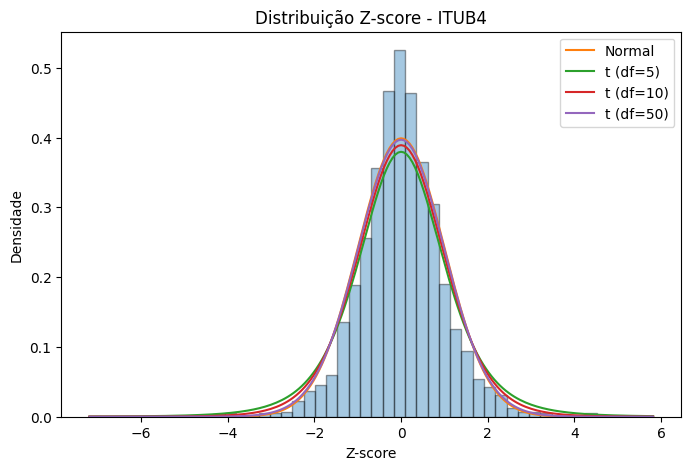

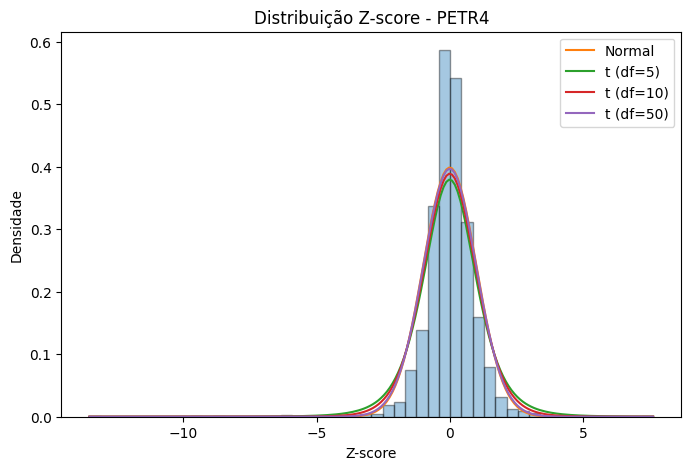

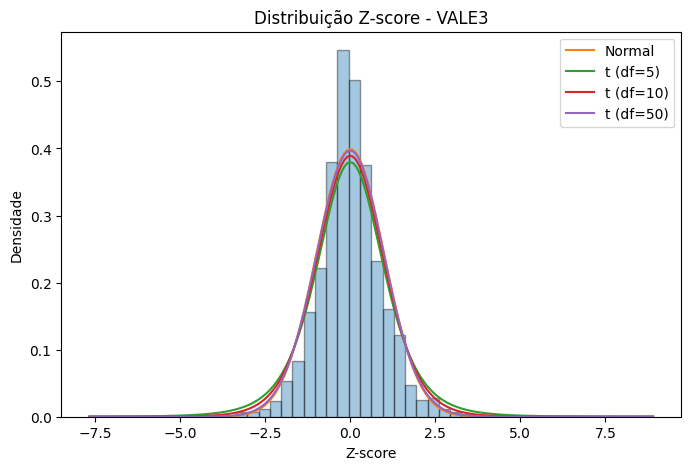

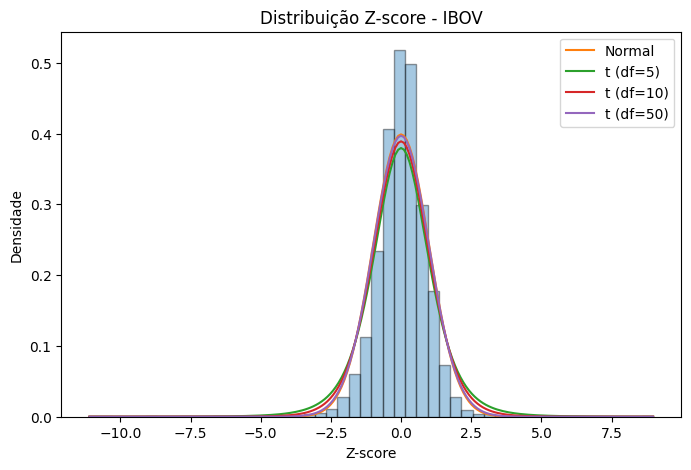

In [36]:
import matplotlib.pyplot as plt

plt.hist(df["z_ABEV3"], bins=50)
plt.title("Histograma do Z-Score - ABEV3")
plt.xlabel("Z-score")
plt.ylabel("Frequência")
plt.show()

plt.hist(df["z_BBDC4"], bins=50)
plt.title("Histograma do Z-Score - BBDC4")
plt.xlabel("Z-score")
plt.ylabel("Frequência")
plt.show()

plt.hist(df["z_ITUB4"], bins=50)
plt.title("Histograma do Z-Score - ITUB4")
plt.xlabel("Z-score")
plt.ylabel("Frequência")
plt.show()

plt.hist(df["z_PETR4"], bins=50)
plt.title("Histograma do Z-Score - PETR4")
plt.xlabel("Z-score")
plt.ylabel("Frequência")
plt.show()

plt.hist(df["z_VALE3"], bins=50)
plt.title("Histograma do Z-Score - VALE3")
plt.xlabel("Z-score")
plt.ylabel("Frequência")
plt.show()

plt.hist(df["z_IBOV"], bins=50)
plt.title("Histograma do Z-Score - IBOV")
plt.xlabel("Z-score")
plt.ylabel("Frequência")
plt.show()

############## curvas de gauss e de t-Student ##################

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm, t

ativos = ["ABEV3", "BBDC4", "ITUB4", "PETR4", "VALE3", "IBOV"]

for ativo in ativos:
    data = df[f"z_{ativo}"].dropna()
    x = np.linspace(data.min(), data.max(), 200)

    mu = data.mean()
    sigma = data.std()

    plt.figure(figsize=(8, 5))
    plt.hist(data, bins=50, density=True, alpha=0.4, edgecolor="black")
    plt.plot(x, norm.pdf(x, mu, sigma), label="Normal")
    plt.plot(x, t.pdf(x, df=5, loc=mu, scale=sigma), label="t (df=5)")
    plt.plot(x, t.pdf(x, df=10, loc=mu, scale=sigma), label="t (df=10)")
    plt.plot(x, t.pdf(x, df=50, loc=mu, scale=sigma), label="t (df=50)")

    plt.title(f"Distribuição Z-score - {ativo}")
    plt.xlabel("Z-score")
    plt.ylabel("Densidade")
    plt.legend()
    plt.show()



A curva de Gauss assume que a maior parte dos valores fica mais perto da média e que valores mais extremos (muito altos ou muito baixos) são raros. Já a t-Student é parecida com a normal, mas dá mais espaço para valores extremos aparecerem. Isso acontece porque ela tem as pontas mais largas (caudas pesadas). Ou seja, enquanto a gaussiana acha que extremos acontecem pouco, a t-Student admite e considera acontecimentos fora do normal (mais extremos).

**Questão 03 - Considerando que os log retornos são normais, calcule a probabilidade de termos um retorno acima de 3%**

In [42]:
from scipy.stats import norm

ativos = ["ABEV3", "BBDC4", "ITUB4", "PETR4", "VALE3", "IBOV"]

for ativo in ativos:
    data = df[f"log_ret_{ativo}"]
    mu = data.mean()
    sigma = data.std()
    prob = 1 - norm.cdf(0.03, loc=mu, scale=sigma)
    print(f"Probabilidade de retorno > 3% para {ativo}: {prob}")

print(prob)

Probabilidade de retorno > 3% para ABEV3: 0.036072368221294115
Probabilidade de retorno > 3% para BBDC4: 0.08151704080616806
Probabilidade de retorno > 3% para ITUB4: 0.050661562709501284
Probabilidade de retorno > 3% para PETR4: 0.13482104515749938
Probabilidade de retorno > 3% para VALE3: 0.08992147768111569
Probabilidade de retorno > 3% para IBOV: 0.020600595555120838
0.020600595555120838


A probabilidade de um retorno superior a 3% é relativamente baixa para todos os ativos analisados, indicando que ganhos mais elevados são eventos pouco frequentes no comportamento dos retornos. 

**Questão 04 - Plote a PDF e a CDF dos log-retornos do seu portfólio.**

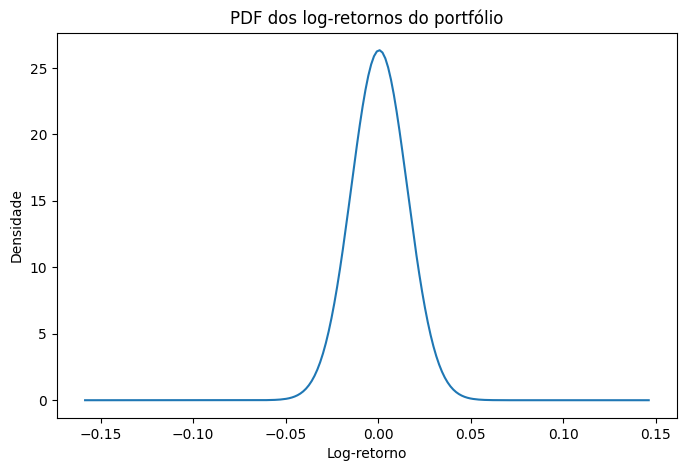

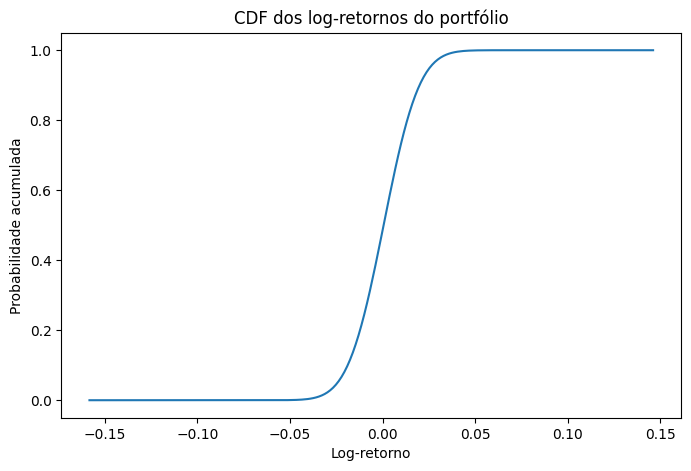

In [44]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

ativos = ["ABEV3", "BBDC4", "ITUB4", "PETR4", "VALE3", "IBOV"]

df["log_ret_portfolio"] = df[[f"log_ret_{ativo}" for ativo in ativos]].mean(axis=1)

data = df["log_ret_portfolio"].dropna()

mu = data.mean()
sigma = data.std()

x = np.linspace(data.min(), data.max(), 200)

# PDF
plt.figure(figsize=(8,5))
plt.plot(x, norm.pdf(x, loc=mu, scale=sigma))
plt.title("PDF dos log-retornos do portfólio")
plt.xlabel("Log-retorno")
plt.ylabel("Densidade")
plt.show()

# CDF
plt.figure(figsize=(8,5))
plt.plot(x, norm.cdf(x, loc=mu, scale=sigma))
plt.title("CDF dos log-retornos do portfólio")
plt.xlabel("Log-retorno")
plt.ylabel("Probabilidade acumulada")
plt.show()

**Questão 05 - Encontre kurtosis e skewness do retornos logarítmicos do seu portfólio. Qual o significado dessas medidas? Quais são os valores para uma normal padrão e qual o significado da diferença desses valores para o seu portfólio e para uma normal padrão?**


In [46]:
df["log_ret_portfolio"] = df[[f"log_ret_{ativo}" for ativo in ativos]].mean(axis=1)

from scipy.stats import skew, kurtosis

data = df["log_ret_portfolio"].dropna()

assimetria = skew(data)
curtose = kurtosis(data)  

print("Skewness:", assimetria)
print("Kurtosis:", curtose)

Skewness: -0.979644086722117
Kurtosis: 17.995455174373003


A skewness mede a assimetria da distribuição dos log-retornos do portfólio. Quando seu valor é igual a zero, a distribuição é simétrica, enquanto que valores positivos indicam cauda mais longa à direita e valores negativos indicam cauda mais longa à esquerda.
A kurtosis mede o peso das caudas da distribuição e a presença de valores extremos. Neste caso, foi utilizado o excesso de curtose, em que a normal padrão possui valor igual a zero. Valores positivos indicam caudas mais pesadas do que as da normal, ou seja, maior probabilidade de eventos extremos; já valores negativos indicam caudas mais leves.
Para a normal padrão, a skewness é igual a 0 e o excesso de kurtosis também é igual a 0. Assim, se os valores encontrados para o portfólio diferirem desses referenciais, isso indica que a distribuição dos retornos do portfólio não segue perfeitamente uma normal. Uma kurtosis maior que a da normal sugere maior risco de movimentos extremos, enquanto uma skewness diferente de zero indica assimetria nos retornos.

**Questão 06 - Considerando que os retornos são normais, calcule o percentil 25% dos retornos e a porcentagem dos dias que teremos retornos negativos**

In [48]:
from scipy.stats import norm

data = df["log_ret_portfolio"].dropna()

mu = data.mean()
sigma = data.std()

p25 = norm.ppf(0.25, loc=mu, scale=sigma)

prob_neg = norm.cdf(0, loc=mu, scale=sigma)

print(f"Percentil 25%: {p25:.4f}")
print(f"Probabilidade de retorno negativo: {prob_neg:.2%}")

Percentil 25%: -0.0096
Probabilidade de retorno negativo: 48.45%


**Questão 07 - O que é o máximo drawdown? Calcule o máximo drawdown do seu portfólio. Interprete o resultado.**


In [51]:
df["ret_portfolio"] = df["log_ret_portfolio"]
df["valor"] = np.exp(df["ret_portfolio"].cumsum())

df["peak"] = df["valor"].cummax()
df["drawdown"] = (df["valor"] - df["peak"]) / df["peak"]

max_dd = df["drawdown"].min()

print(f"Máximo drawdown: {max_dd:.2%}")

Máximo drawdown: -44.87%


O máximo drawdown representa a maior queda acumulada do valor do portfólio a partir de um pico até o ponto mais baixo seguinte. Essa medida é amplamente utilizada para avaliar o risco de perdas em investimentos visto que indica o pior cenário de perda enfrentado ao longo do período analisado.
O valor encontrado indica que, em determinado momento, o portfólio sofreu uma queda máxima de aproximadamente X%, refletindo a magnitude da maior perda acumulada. Quanto maior o drawdown, maior o risco associado ao investimento, especialmente para investidores mais avessos a perdas.

**Questão 08 - Teste se os retornos do portfólio são estatisticamente diferentes de zero e do retorno do índice BOVESPA. Qual alpha você utilizaria?**

In [52]:
from scipy import stats

port = df["log_ret_portfolio"].dropna()
ibov = df["log_ret_IBOV"].dropna()

# Teste 1: média = 0
t1 = stats.ttest_1samp(port, 0)

# Teste 2: média portfólio = média IBOV
t2 = stats.ttest_ind(port, ibov)

print("Teste 1 (retorno = 0):", t1)
print("Teste 2 (portfólio vs IBOV):", t2)

Teste 1 (retorno = 0): TtestResult(statistic=np.float64(1.828791173376049), pvalue=np.float64(0.0675661500166248), df=np.int64(2201))
Teste 2 (portfólio vs IBOV): TtestResult(statistic=np.float64(0.21922026309919002), pvalue=np.float64(0.8264886352897106), df=np.float64(4402.0))


O alpha representa a probabilidade máxima de cometer um erro ao rejeitar a hipótese nula quando ela é verdadeira e eu utilizaria um valor α igual a 0,05, uma vez que valores menores, como 1%, tornam o teste mais conservador, enquanto valores maiores, como 10%, aumentam a probabilidade de erros. 